# 03.1 - Eficiência do SAM 2: memória de objeto vs. cor por frame

## Objetivo

Comparar o SAM 2 Tiny com uma técnica clássica, simples e orientada por
um clique: selecionar em cada frame todos os pixels cuja cor é próxima
à cor do ponto positivo. O experimento contém dois objetos azuis. O
baseline conhece a aparência, mas não entende limites nem identidade;
o SAM 2 recebe o mesmo clique e usa representação de objeto e memória.

A comparação mede duas eficiências diferentes:

- **computacional:** tempo e FPS locais;
- **da tarefa/interação:** IoU, precisão, recall e quantidade de prompts.

O baseline deve ser mais rápido. O ponto do experimento é verificar se
o custo adicional do SAM 2 resolve a seleção do objeto correto.

In [1]:
from pathlib import Path


def locate_seminar_dir():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        seminar = candidate if candidate.name == "seminar_2" else candidate / "seminar_2"
        if (seminar / "articles").is_dir():
            return seminar
    raise FileNotFoundError("Execute este notebook dentro do repositório TP558.")


SEMINAR_DIR = locate_seminar_dir()
DATA_DIR = SEMINAR_DIR / "data"
OUTPUT_DIR = DATA_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(SEMINAR_DIR)

/home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/seminar_2


## 1. Preparação dos dados

O círculo azul é o alvo e se move para a direita. O quadrado azul é um
distrator com a mesma cor. A máscara de referência contém somente o
círculo; ambos os métodos recebem um clique positivo no centro do alvo
no primeiro frame.

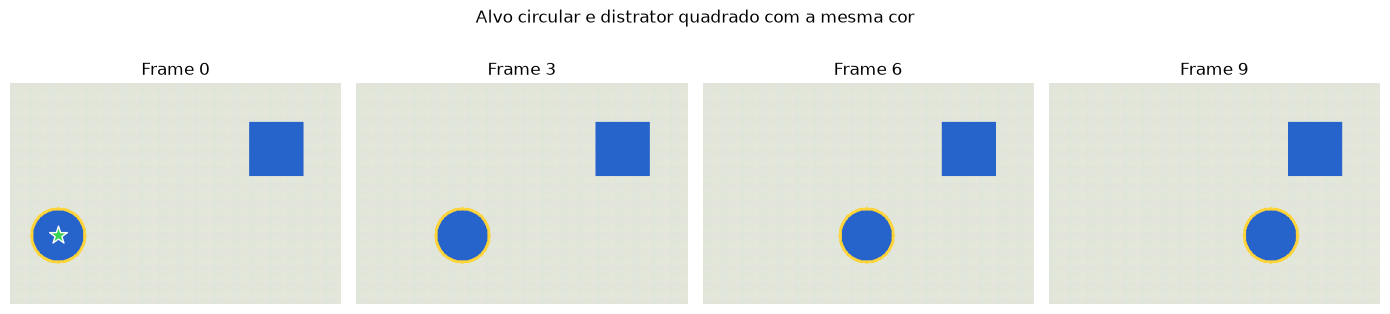

In [2]:
import csv
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.patches import Patch
from PIL import Image

FRAME_DIR = DATA_DIR / "raw" / "comparison_video"
GT_DIR = DATA_DIR / "processed" / "comparison_gt_masks"
CHECKPOINT = DATA_DIR / "models" / "sam2.1_hiera_tiny.pt"
CONFIG = "configs/sam2.1/sam2.1_hiera_t.yaml"
FRAME_DIR.mkdir(parents=True, exist_ok=True)
GT_DIR.mkdir(parents=True, exist_ok=True)

height, width, n_frames = 240, 360, 10
yy, xx = np.mgrid[:height, :width]
frames, ground_truth = [], []

for index in range(n_frames):
    center_x, center_y, radius = 52 + 21 * index, 165, 29
    target = (xx - center_x) ** 2 + (yy - center_y) ** 2 <= radius ** 2
    distractor = (xx >= 260) & (xx <= 318) & (yy >= 42) & (yy <= 100)

    frame = np.empty((height, width, 3), dtype=np.uint8)
    frame[..., 0] = 224 + (xx % 20) // 4
    frame[..., 1] = 228 + (yy % 18) // 4
    frame[..., 2] = 218
    frame[target | distractor] = (38, 99, 202)

    frames.append(frame)
    ground_truth.append(target)
    Image.fromarray(frame).save(FRAME_DIR / f"{index:05d}.jpg", quality=95)
    Image.fromarray((target * 255).astype(np.uint8)).save(GT_DIR / f"{index:05d}.png")

point = np.array([[52, 165]], dtype=np.float32)
label = np.array([1], dtype=np.int32)
assert all(mask[165, 52 + 21 * index] for index, mask in enumerate(ground_truth))

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, index in zip(axes, [0, 3, 6, 9], strict=True):
    ax.imshow(frames[index])
    ax.contour(ground_truth[index], [0.5], colors=["#ffd43b"], linewidths=2)
    if index == 0:
        ax.scatter(*point[0], marker="*", s=180, c="#39d353", edgecolors="white")
    ax.set_title(f"Frame {index}")
    ax.axis("off")
fig.suptitle("Alvo circular e distrator quadrado com a mesma cor")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "comparison_dataset.png", dpi=180, bbox_inches="tight")
plt.show()

## 2. Baseline clássico: distância de cor

A cor do clique no primeiro frame define o alvo. Em cada frame, todo
pixel a uma distância RGB menor que 45 é marcado. Não há treinamento,
noção de contorno, estado temporal ou classe semântica.

In [3]:
seed_x, seed_y = point[0].astype(int)
seed_color = frames[0][seed_y, seed_x].astype(np.int16)

start = time.perf_counter()
color_predictions = [
    np.linalg.norm(frame.astype(np.int16) - seed_color, axis=2) < 45
    for frame in frames
]
color_seconds = time.perf_counter() - start
color_fps = n_frames / color_seconds
print(f"Baseline: {color_seconds:.4f} s, {color_fps:.1f} FPS")

Baseline: 0.0159 s, 627.3 FPS


## 3. SAM 2 Tiny

O mesmo clique inicializa o masklet. O tempo de construção do modelo é
separado do tempo de inicialização/propagação. Em CPU a execução é
válida, mas não comparável aos FPS publicados em GPU A100.

In [4]:
if not CHECKPOINT.exists():
    raise FileNotFoundError(f"Checkpoint não encontrado: {CHECKPOINT}")

from sam2.build_sam import build_sam2_video_predictor

device = "cuda" if torch.cuda.is_available() else "cpu"
load_start = time.perf_counter()
predictor = build_sam2_video_predictor(CONFIG, str(CHECKPOINT), device=device)
model_load_seconds = time.perf_counter() - load_start
parameter_count = sum(parameter.numel() for parameter in predictor.parameters())

inference_start = time.perf_counter()
state = predictor.init_state(video_path=str(FRAME_DIR))
sam2_by_frame = {}
with torch.inference_mode():
    predictor.add_new_points_or_box(
        inference_state=state,
        frame_idx=0,
        obj_id=1,
        points=point,
        labels=label,
    )
    for frame_index, object_ids, mask_logits in predictor.propagate_in_video(state):
        object_position = list(object_ids).index(1)
        sam2_by_frame[frame_index] = (mask_logits[object_position, 0] > 0).cpu().numpy()
sam2_seconds = time.perf_counter() - inference_start
sam2_predictions = [sam2_by_frame[index] for index in range(n_frames)]
sam2_fps = n_frames / sam2_seconds

print(f"Dispositivo: {device}")
print(f"Parâmetros: {parameter_count / 1e6:.1f} M")
print(f"Carga do modelo: {model_load_seconds:.2f} s")
print(f"Inferência: {sam2_seconds:.2f} s, {sam2_fps:.2f} FPS")
assert len(sam2_predictions) == n_frames

frame loading (JPEG): 100%|██████████| 10/10 [00:00<00:00, 70.04it/s]
/home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/seminar_2/data/models/sam2-source/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/seminar_2/data/models/sam2-source/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 10/10 [00:15<00:00,  1.60s/it]

Dispositivo: cpu
Parâmetros: 39.0 M
Carga do modelo: 0.44 s
Inferência: 17.30 s, 0.58 FPS


## 4. Métricas

IoU mede a sobreposição total; precisão penaliza o distrator incluído;
recall penaliza partes ausentes do círculo. O número de prompts é um
para ambos os métodos.

In [5]:
def segmentation_metrics(prediction, target):
    tp = np.logical_and(prediction, target).sum()
    fp = np.logical_and(prediction, ~target).sum()
    fn = np.logical_and(~prediction, target).sum()
    return (
        tp / (tp + fp + fn) if tp + fp + fn else 1.0,
        tp / (tp + fp) if tp + fp else 1.0,
        tp / (tp + fn) if tp + fn else 1.0,
    )


color_metrics = np.array([segmentation_metrics(pred, target) for pred, target in zip(color_predictions, ground_truth, strict=True)])
sam2_metrics = np.array([segmentation_metrics(pred, target) for pred, target in zip(sam2_predictions, ground_truth, strict=True)])

summary = {
    "Cor por frame": (*color_metrics.mean(axis=0), color_seconds, color_fps, 1),
    "SAM 2 Tiny": (*sam2_metrics.mean(axis=0), sam2_seconds, sam2_fps, 1),
}
metrics_path = OUTPUT_DIR / "comparison_metrics.csv"
with metrics_path.open("w", newline="", encoding="utf-8") as stream:
    writer = csv.writer(stream)
    writer.writerow(["method", "mean_iou", "mean_precision", "mean_recall", "seconds", "fps", "prompts"])
    writer.writerows((method, *values) for method, values in summary.items())

for method, (mean_iou, mean_precision, mean_recall, seconds, fps, prompts) in summary.items():
    print(f"{method:14} IoU={mean_iou:.3f}  precisão={mean_precision:.3f}  recall={mean_recall:.3f}  FPS={fps:.2f}  prompts={prompts}")
assert all(0 <= values[0] <= 1 for values in summary.values())

Cor por frame  IoU=0.430  precisão=0.430  recall=1.000  FPS=627.32  prompts=1
SAM 2 Tiny     IoU=0.992  precisão=0.993  recall=1.000  FPS=0.58  prompts=1


## 5. Visualização comparativa

A sobreposição em ciano representa a predição; o contorno amarelo é a
referência. No mapa de erros, vermelho revela pixels do distrator que
foram incorretamente incluídos e magenta indica partes omitidas do alvo.

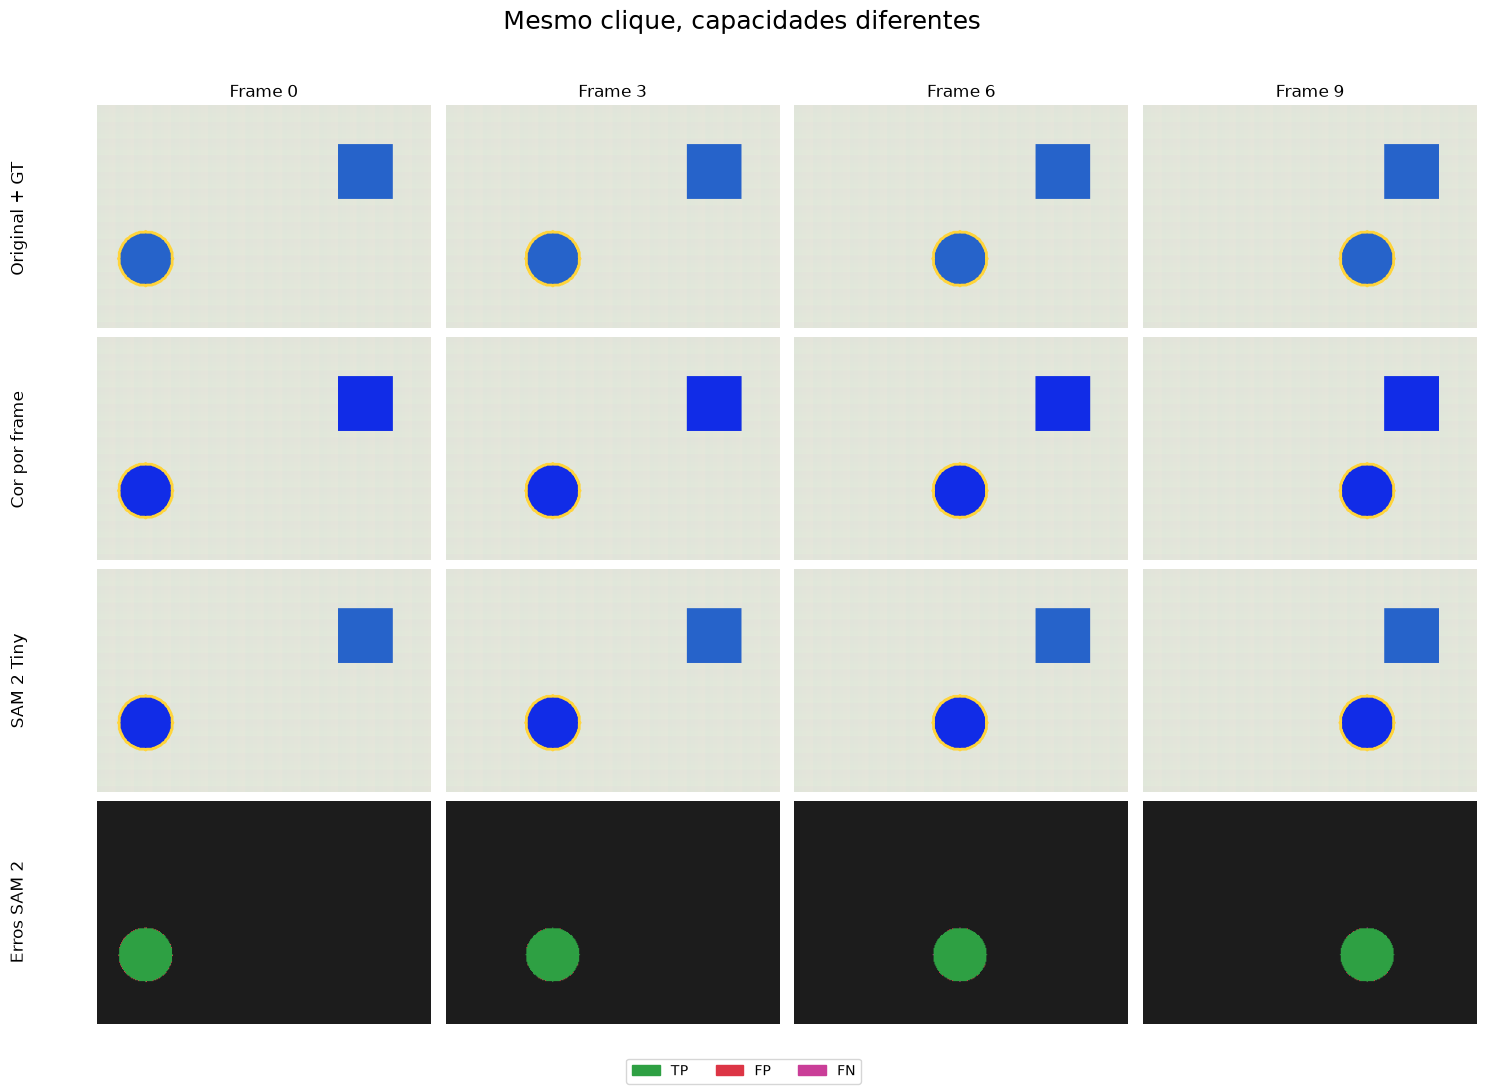

In [6]:
selected_frames = [0, 3, 6, 9]
fig, axes = plt.subplots(4, len(selected_frames), figsize=(15, 11))

for column, frame_index in enumerate(selected_frames):
    frame = frames[frame_index]
    target = ground_truth[frame_index]
    color_mask = color_predictions[frame_index]
    sam2_mask = sam2_predictions[frame_index]

    axes[0, column].imshow(frame)
    axes[0, column].contour(target, [0.5], colors=["#ffd43b"], linewidths=2)

    for row, prediction in [(1, color_mask), (2, sam2_mask)]:
        axes[row, column].imshow(frame)
        axes[row, column].imshow(np.ma.masked_where(~prediction, prediction), cmap="winter", alpha=0.55)
        axes[row, column].contour(target, [0.5], colors=["#ffd43b"], linewidths=2)

    error_map = np.full((*target.shape, 3), 28, dtype=np.uint8)
    error_map[np.logical_and(target, sam2_mask)] = (46, 160, 67)
    error_map[np.logical_and(~target, sam2_mask)] = (220, 53, 69)
    error_map[np.logical_and(target, ~sam2_mask)] = (202, 62, 152)
    axes[3, column].imshow(error_map)

    axes[0, column].set_title(f"Frame {frame_index}")
    for row in range(4):
        axes[row, column].axis("off")

for y, label_text in zip([0.79, 0.58, 0.37, 0.16], ["Original + GT", "Cor por frame", "SAM 2 Tiny", "Erros SAM 2"], strict=True):
    fig.text(0.012, y, label_text, rotation=90, va="center", fontsize=12)

fig.legend(
    handles=[Patch(color="#2ea043", label="TP"), Patch(color="#dc3545", label="FP"), Patch(color="#ca3e98", label="FN")],
    loc="lower center",
    ncols=3,
)
fig.suptitle("Mesmo clique, capacidades diferentes", fontsize=18)
fig.tight_layout(rect=(0.06, 0.04, 1, 0.96))
fig.savefig(OUTPUT_DIR / "comparison_visual.png", dpi=180, bbox_inches="tight")
plt.show()

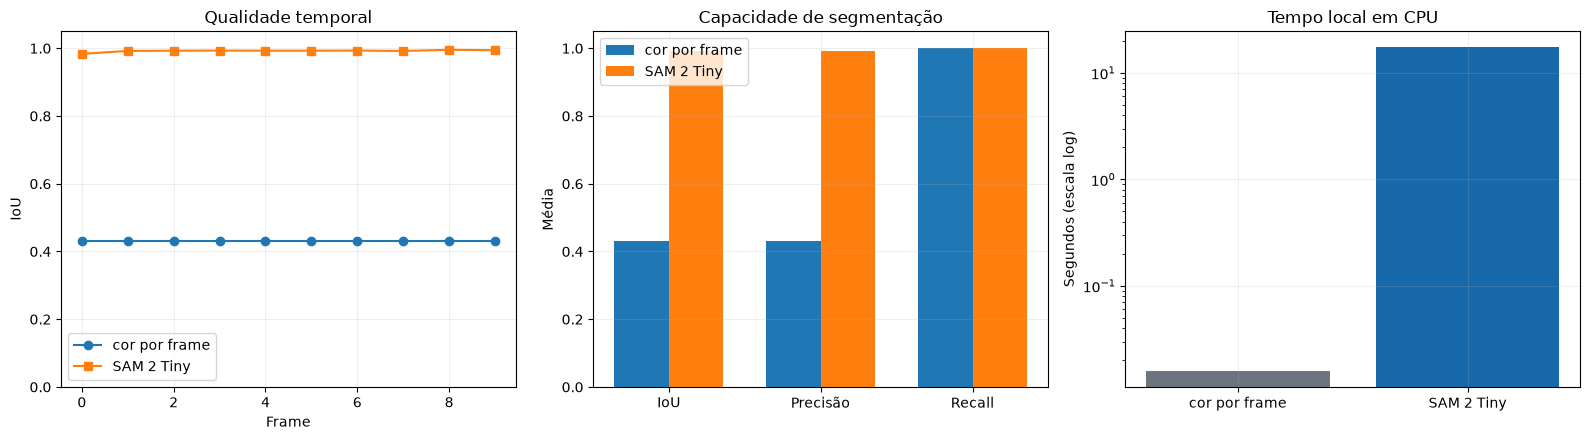

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
frame_axis = np.arange(n_frames)

axes[0].plot(frame_axis, color_metrics[:, 0], marker="o", label="cor por frame")
axes[0].plot(frame_axis, sam2_metrics[:, 0], marker="s", label="SAM 2 Tiny")
axes[0].set(xlabel="Frame", ylabel="IoU", ylim=(0, 1.05), title="Qualidade temporal")
axes[0].legend()

metric_names = ["IoU", "Precisão", "Recall"]
x = np.arange(3)
axes[1].bar(x - 0.18, color_metrics.mean(axis=0), 0.36, label="cor por frame")
axes[1].bar(x + 0.18, sam2_metrics.mean(axis=0), 0.36, label="SAM 2 Tiny")
axes[1].set_xticks(x, metric_names)
axes[1].set(ylabel="Média", ylim=(0, 1.05), title="Capacidade de segmentação")
axes[1].legend()

runtime_values = [color_seconds, sam2_seconds]
axes[2].bar(["cor por frame", "SAM 2 Tiny"], runtime_values, color=["#6c757d", "#1769aa"])
axes[2].set_yscale("log")
axes[2].set(ylabel="Segundos (escala log)", title=f"Tempo local em {device.upper()}")

for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "comparison_metrics.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Discussão

A técnica de cor é computacionalmente muito mais barata e recupera os
pixels azuis do círculo, portanto tende a ter recall alto. Entretanto,
ela também marca o quadrado azul: aparência local não basta para manter
a identidade solicitada pelo clique, o que reduz precisão e IoU.

Nesta execução, o baseline obteve IoU 0,430 e o SAM 2 Tiny 0,992, ambos
com um prompt. Em CPU, o SAM 2 processou aproximadamente 0,60 FPS, enquanto
o limiar de cor ultrapassou 500 FPS.

O SAM 2 resolve uma tarefa mais geral. O prompt define uma instância; o
encoder representa forma e limites; a memória propaga essa instância.
Assim, sua eficiência aparece na qualidade obtida com um único clique e
sem regra específica para “círculo azul”. O custo é maior tempo de
inferência. Tiny reduz esse custo dentro da família SAM 2, mas não deve
ser descrito como mais rápido que um limiar de cor. A extensão opcional
`_C` não estava disponível nesta instalação CPU, então o pós-processamento
de preenchimento de pequenos buracos foi ignorado.

O experimento também delimita a conclusão: dados sintéticos e dez
frames não formam benchmark. A evidência é didática sobre seleção de
instância e memória, complementando os resultados quantitativos do
paper em datasets reais.

## 7. Conclusões para o seminário

- Mesma cor não significa mesmo objeto; SAM 2 responde ao prompt como
  seleção de instância.
- Um prompt é propagado ao vídeo inteiro pela memória streaming.
- Eficiência deve separar custo computacional de eficiência de interação.
- Tiny torna a demonstração mais acessível, com possível perda de
  robustez em casos difíceis.
- Baselines simples continuam úteis quando o domínio é controlado; SAM 2
  se destaca quando a regra precisa generalizar para objetos variados.